In [1]:
from qiskit import *
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#   ────────────────────────────── Configuration ───────────────────────────────
#%matplotlib widget
# Dataset
N          = 500    # Number of generated points
TEST_SIZE  = 0.2     # Fraction used for test set
SEED       = 1       # Random seed (data split & optimizer init)

# Model
RC         = 4       # Number of circuit layers

# Optimization
MAXITER    = 300     # COBYLA max iterations

# Simulation
USE_NOISE  = True    # True -> noisy AerSimulator | False -> Statevector
NOISE_RATE = 0.005   # Depolarizing error rate per gate
SHOTS      = 1024    # Number of shots

# AdaBoost
N_ESTIMATORS = 5     # Number of weak QNN classifiers in the ensemble


# Data generation

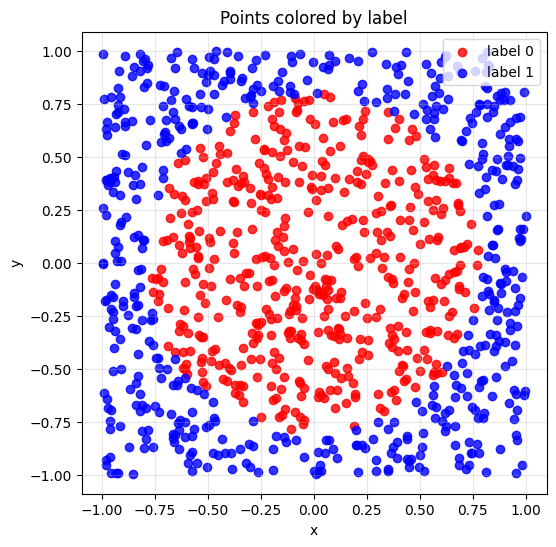

points in label 0: 483
points in label 1: 517


In [3]:
points = np.random.rand(N, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))


In [4]:
rng = np.random.default_rng(SEED)

indices   = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - TEST_SIZE))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


X_train: (800, 2) y_train: (800,)
X_test : (200, 2) y_test : (200,)


In [5]:
def U_su2(q, theta, omega, x, qubit):
    x3d = [x[0], x[1], 0] # Add a third dimension with value 0
    # phi_i = theta_i + w_i * x_i
    val_0 = theta[0] + omega[0] * x3d[0]
    val_1 = theta[1] + omega[1] * x3d[1]
    val_2 = theta[2] + omega[2] * x3d[2]
    
    q.u(val_0, val_1, val_2, qubit)

In [6]:
def create_circuit(x, theta, omega, measure=True):
    qc = QuantumCircuit(1)
    for i in range(RC):
        qc.h(0)
        U_su2(qc, theta[i], omega[i], x, 0)
    if measure:
        qc.measure_all()
    return qc


In [7]:
theta = [[1, 1, 1] for _ in range(RC)]
omega = [[1, 1, 1] for _ in range(RC)]
qc = create_circuit(X_train[0], theta, omega)
qc.draw()


┌───┐┌──────────────────────┐┌───┐┌──────────────────────┐┌───┐»
     q: ┤ H ├┤ U(0.80571,0.35221,1) ├┤ H ├┤ U(0.80571,0.35221,1) ├┤ H ├»
        └───┘└──────────────────────┘└───┘└──────────────────────┘└───┘»
meas: 1/═══════════════════════════════════════════════════════════════»
                                                                       »
«        ┌──────────────────────┐┌───┐┌──────────────────────┐ ░ ┌─┐
«     q: ┤ U(0.80571,0.35221,1) ├┤ H ├┤ U(0.80571,0.35221,1) ├─░─┤M├
«        └──────────────────────┘└───┘└──────────────────────┘ ░ └╥┘
«meas: 1/═════════════════════════════════════════════════════════╩═
«                                                                 0

In [8]:
def build_simulator():
    if USE_NOISE:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(NOISE_RATE, 1), ['u'])
        return AerSimulator(noise_model=nm)
    return StatevectorSimulator()

sv_sim = build_simulator()

def get_probs_batch(circuits):
    """
    Returns a list of (p0, p1) for each circuit.
    Noiseless: exact statevector amplitudes.
    Noisy:     shot-based counts normalised by SHOTS.
    """
    if USE_NOISE:
        meas = [c.copy() for c in circuits]
        for c in meas:
            c.measure_all()
        compiled = transpile(meas, sv_sim)
        results  = sv_sim.run(compiled, shots=SHOTS).result()
        return [
            (results.get_counts(i).get('0', 0) / SHOTS,
             results.get_counts(i).get('1', 0) / SHOTS)
            for i in range(len(meas))
        ]
    else:
        compiled = transpile(circuits, sv_sim)
        results  = sv_sim.run(compiled).result()
        return [
            (float(np.abs(results.get_statevector(i).data[0])**2),
             float(np.abs(results.get_statevector(i).data[1])**2))
            for i in range(len(circuits))
        ]


In [9]:
def cost_function_weighted(params, X_train, y_train):
    theta  = params[:3 * RC].reshape(RC, 3)
    omega  = params[3 * RC:6 * RC].reshape(RC, 3)
    alphas = params[6 * RC:]   # alpha_0, alpha_1

    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    probs    = get_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y_train):
        f0, f1     = probs[i]
        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]
        total_cost += (alphas[0] * f0 - y_expected[0])**2
        total_cost += (alphas[1] * f1 - y_expected[1])**2

    return 0.5 * (total_cost / len(y_train))


In [10]:
def unpack_params(params):
    theta  = params[:3 * RC].reshape(RC, 3)
    omega  = params[3 * RC:6 * RC].reshape(RC, 3)
    alphas = params[6 * RC:]
    return theta, omega, alphas

def optimize_parameters(X_train, y_train):
    rng  = np.random.default_rng(SEED)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC + 2)

    cache = {"cost": None}
    cost_history = []
    step = {"k": 0}

    def objective(params):
        cost = cost_function_weighted(params, X_train, y_train)
        cache["cost"] = cost
        return cost

    def cb(xk):
        step["k"] += 1
        cost_history.append(cache["cost"])
        print(f"Step {step['k']:03d} | cost = {cache['cost']:.6f}")

    res = minimize(objective, init, method="COBYLA",
                   callback=cb, options={"maxiter": MAXITER})

    theta_opt, omega_opt, _ = unpack_params(res.x)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res, cost_history


In [11]:
def predict_batch(X, theta, omega):
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    probs    = get_probs_batch(circuits)
    return np.array([0 if p0 >= 0.5 else 1 for p0, _ in probs])

def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred    = predict_batch(X, theta, omega)
    tp        = np.sum((y_pred == positive_label) & (y == positive_label))
    fp        = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy  = np.mean(y_pred == y)
    return precision, accuracy, y_pred

mode_label = "Noisy" if USE_NOISE else "Noiseless"
sv_sim = build_simulator()

theta_opt, omega_opt, res, cost_history = optimize_parameters(X_train, y_train)
precision_test, accuracy_test, y_pred = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print(f"[{mode_label}] Final train cost:", res.fun)
print(f"[{mode_label}] Test precision:", precision_test)
print(f"[{mode_label}] Test accuracy:", accuracy_test)


Step 001 | cost = 1.237345
Step 002 | cost = 1.396552
Step 003 | cost = 0.860041
Step 004 | cost = 0.686540
Step 005 | cost = 0.604686
Step 006 | cost = 0.693349
Step 007 | cost = 1.177124
Step 008 | cost = 0.574489
Step 009 | cost = 0.972587
Step 010 | cost = 0.674403
Step 011 | cost = 0.820412
Step 012 | cost = 0.576905
Step 013 | cost = 0.636328
Step 014 | cost = 0.566830
Step 015 | cost = 0.563819
Step 016 | cost = 0.565898
Step 017 | cost = 0.676196
Step 018 | cost = 0.673385
Step 019 | cost = 0.562985
Step 020 | cost = 0.602646
Step 021 | cost = 0.599698
Step 022 | cost = 0.560584
Step 023 | cost = 0.490541
Step 024 | cost = 0.490776
Step 025 | cost = 0.488630
Step 026 | cost = 0.634205
Step 027 | cost = 1.179978
Step 028 | cost = 0.442686
Step 029 | cost = 0.468426
Step 030 | cost = 0.437219
Step 031 | cost = 0.532550
Step 032 | cost = 0.546176
Step 033 | cost = 0.405519
Step 034 | cost = 0.920106
Step 035 | cost = 0.437138
Step 036 | cost = 0.518082
Step 037 | cost = 0.433596
S

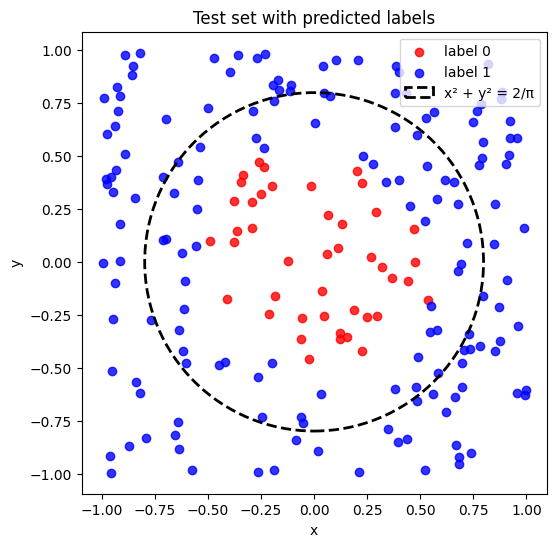

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)
r = np.sqrt(2 / np.pi)
circle = plt.Circle((0, 0), r, color="black", fill=False, linestyle="--", linewidth=2, label="x² + y² = 2/π")
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Test set with predicted labels")
plt.legend()
plt.show()

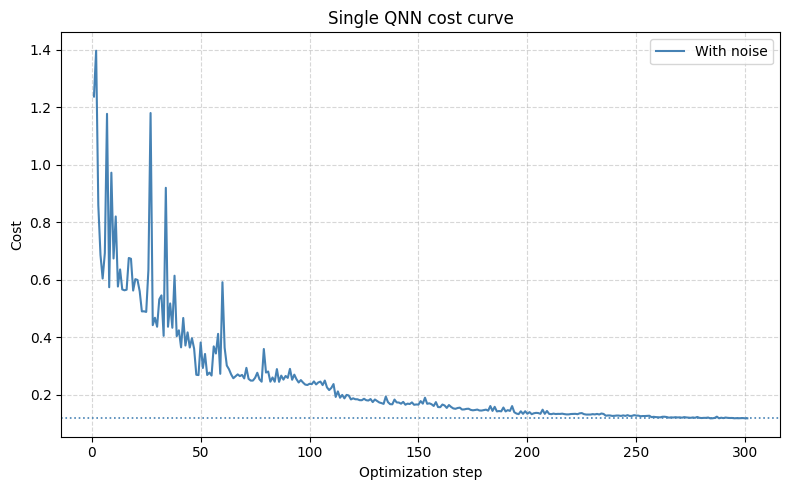

In [13]:
plt.figure(figsize=(8, 5))
ax1 = plt.subplot(1, 1, 1)

ax1.plot(
    range(1, len(cost_history) + 1),
    cost_history,
    color="steelblue" if USE_NOISE else "darkorange",
    linewidth=1.5,
    label="With noise" if USE_NOISE else "Without noise"
)
ax1.axhline(
    res.fun,
    color="steelblue" if USE_NOISE else "darkorange",
    linestyle=":",
    linewidth=1.2
)

ax1.set_xlabel("Optimization step")
ax1.set_ylabel("Cost")
ax1.set_title("Single QNN cost curve")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

plt.tight_layout()
plt.show()


# AdaBoost Ensemble of Weak QNN Classifiers

AdaBoost trains `N_ESTIMATORS` QNNs sequentially. After each round the training sample weights are updated to emphasise the points that were misclassified, forcing the next estimator to focus on harder examples. The final prediction is a **weighted majority vote** over all estimators.

In [14]:
def cost_fn_weighted_samples(params, X, y, sample_weights):
    theta = params[:3 * RC].reshape(RC, 3)
    omega = params[3 * RC:6 * RC].reshape(RC, 3)

    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    probs = get_probs_batch(circuits)

    total = 0.0
    for i, y_t in enumerate(y):
        p0, p1 = probs[i]
        e0, e1 = (1.0, 0.0) if y_t == 0 else (0.0, 1.0)
        total += sample_weights[i] * ((p0 - e0) ** 2 + (p1 - e1) ** 2)

    return 0.5 * total / np.sum(sample_weights)


def optimize_weak_learner(X, y, sample_weights, seed):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC)

    res = minimize(
        cost_fn_weighted_samples,
        init,
        args=(X, y, sample_weights),
        method="COBYLA",
        options={"maxiter": MAXITER},
    )

    theta = res.x[:3 * RC].reshape(RC, 3)
    omega = res.x[3 * RC:].reshape(RC, 3)
    return theta, omega, res.fun


def train_adaboost(X_train, y_train, n_estimators=N_ESTIMATORS):
    n = len(y_train)
    weights = np.ones(n) / n
    estimators = []

    for i in range(n_estimators):
        theta, omega, cost = optimize_weak_learner(
            X_train, y_train, weights, seed=SEED + i
        )

        y_pred = predict_batch(X_train, theta, omega)
        incorrect = (y_pred != y_train).astype(float)
        eps = np.dot(weights, incorrect)
        eps = np.clip(eps, 1e-10, 1 - 1e-10)

        alpha = 0.5 * np.log((1 - eps) / eps)

        y_signed = np.where(y_train == 0, -1.0, 1.0)
        h_signed = np.where(y_pred == 0, -1.0, 1.0)
        weights *= np.exp(-alpha * y_signed * h_signed)
        weights /= np.sum(weights)

        estimators.append((theta, omega, alpha))
        print(f"round {i + 1:02d} | cost={cost:.4f} eps={eps:.4f} alpha={alpha:.4f}")

    return estimators


def predict_adaboost(X, estimators):
    scores = np.zeros(len(X))
    for theta, omega, alpha in estimators:
        h_signed = np.where(predict_batch(X, theta, omega) == 0, -1.0, 1.0)
        scores += alpha * h_signed
    return np.where(scores >= 0, 1, 0)


def evaluate_adaboost(X, y, estimators, positive_label=1):
    y_pred = predict_adaboost(X, estimators)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    fn = np.sum((y_pred != positive_label) & (y == positive_label))
    tn = np.sum((y_pred != positive_label) & (y != positive_label))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = np.mean(y_pred == y)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "precision": precision,
        "accuracy": accuracy,
        "recall": recall,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "y_pred": y_pred,
    }

In [15]:
mode_label = "Noisy" if USE_NOISE else "Noiseless"

print(f"=== AdaBoost ({mode_label.lower()}) ===")
estimators_boost = train_adaboost(X_train, y_train, n_estimators=N_ESTIMATORS)

metrics_boost = evaluate_adaboost(X_test, y_test, estimators_boost)
precision_boost = metrics_boost["precision"]
accuracy_boost = metrics_boost["accuracy"]
y_pred_boost = metrics_boost["y_pred"]

print("\nSingle QNN")
print(f"precision={precision_test:.4f} | accuracy={accuracy_test:.4f}")

print("\nAdaBoost")
print(f"precision={precision_boost:.4f} | recall={metrics_boost['recall']:.4f} | accuracy={accuracy_boost:.4f}")
print(
    f"TP={metrics_boost['tp']} FP={metrics_boost['fp']} "
    f"FN={metrics_boost['fn']} TN={metrics_boost['tn']}"
)

=== AdaBoost (noisy) ===
round 01 | cost=0.0945 eps=0.0800 alpha=1.2212


KeyboardInterrupt: 

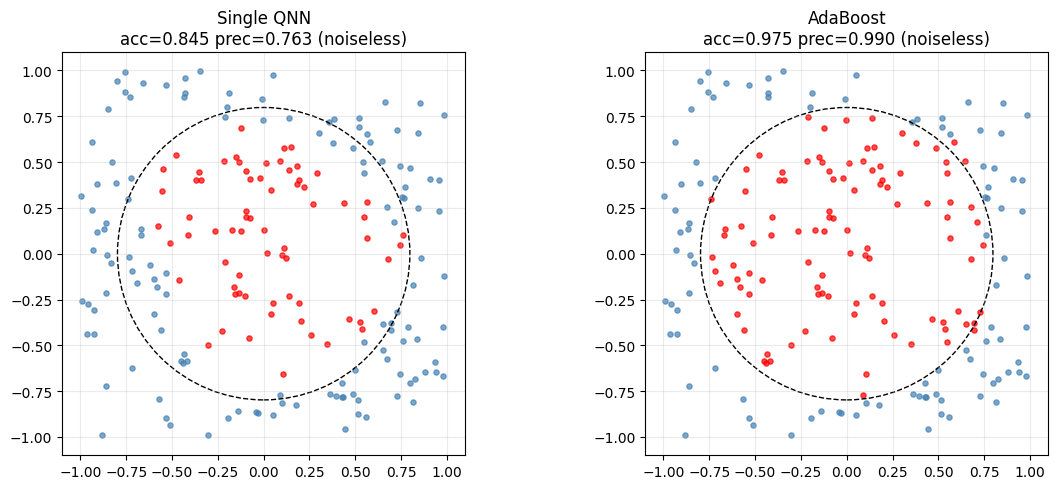

In [ ]:
r = np.sqrt(2 / np.pi)
mode_label = "Noisy" if USE_NOISE else "Noiseless"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (y_pred, f"Single QNN\nacc={accuracy_test:.3f} prec={precision_test:.3f}"),
    (y_pred_boost, f"AdaBoost\nacc={accuracy_boost:.3f} prec={precision_boost:.3f}"),
]

for ax, (pred, title) in zip(axes, plots):
    ax.scatter(X_test[pred == 0][:, 0], X_test[pred == 0][:, 1], c="red", s=14, alpha=0.7)
    ax.scatter(X_test[pred == 1][:, 0], X_test[pred == 1][:, 1], c="steelblue", s=14, alpha=0.7)
    ax.add_patch(plt.Circle((0, 0), r, color="black", fill=False, linestyle="--"))
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title} ({mode_label.lower()})")

plt.tight_layout()
plt.show()

# Confusion matrices
Visual comparison of classification errors for Single QNN and AdaBoost on the test set.

In [ ]:
def confusion_matrix_2x2(y_true, y_pred, positive_label=1):
    tp = np.sum((y_pred == positive_label) & (y_true == positive_label))
    fp = np.sum((y_pred == positive_label) & (y_true != positive_label))
    fn = np.sum((y_pred != positive_label) & (y_true == positive_label))
    tn = np.sum((y_pred != positive_label) & (y_true != positive_label))
    return np.array([[tn, fp], [fn, tp]], dtype=int)

cm_single = confusion_matrix_2x2(y_test, y_pred, positive_label=1)
cm_boost = confusion_matrix_2x2(y_test, y_pred_boost, positive_label=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cms = [
    (cm_single, "Single QNN"),
    (cm_boost, "AdaBoost"),
]

for ax, (cm, title) in zip(axes, cms):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([0, 1])
    ax.set_yticks([0, 1])
    ax.set_yticklabels([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
plt.tight_layout()
plt.show()

print("Single QNN confusion matrix [[TN, FP], [FN, TP]]:")
print(cm_single)
print("\nAdaBoost confusion matrix [[TN, FP], [FN, TP]]:")
print(cm_boost)